In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
train_dir = "/kaggle/input/datasets/msambare/fer2013/train"
test_dir = "/kaggle/input/datasets/msambare/fer2013/test"

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']
Test folders: ['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [3]:
# Create output folders for assignment files
os.makedirs("/kaggle/working/outputs/figures", exist_ok=True)
os.makedirs("/kaggle/working/outputs/tables", exist_ok=True)

print("Output folders created successfully")

Output folders created successfully


In [4]:
# Data generators with preprocessing

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [5]:
# Display class labels

print("Class Labels:")
print(train_data.class_indices)

Class Labels:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [6]:
# Save class labels as CSV table

class_labels = pd.DataFrame(
    list(train_data.class_indices.items()),
    columns=["Emotion_Class", "Class_Index"]
)

class_labels.to_csv("/kaggle/working/outputs/tables/class_labels.csv", index=False)

class_labels

,Emotion_Class,Class_Index
0,angry,0
1,disgust,1
2,fear,2
3,happy,3
4,neutral,4
5,sad,5
6,surprise,6


In [8]:
# Build CNN model

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 605s 1s/step - accuracy: 0.2273 - loss: 1.8406 - val_accuracy: 0.2657 - val_loss: 1.7825
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 106s 236ms/step - accuracy: 0.2687 - loss: 1.7851 - val_accuracy: 0.3434 - val_loss: 1.6913
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 85s 189ms/step - accuracy: 0.3150 - loss: 1.7287 - val_accuracy: 0.3826 - val_loss: 1.6338
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 80s 178ms/step - accuracy: 0.3297 - loss: 1.6906 - val_accuracy: 0.3913 - val_loss: 1.5903
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 78s 174ms/step - accuracy: 0.3518 - loss: 1.6626 - val_accuracy: 0.3982 - val_loss: 1.5727
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.3584 - loss: 1.6441 - val_accuracy: 0.4122 - val_loss: 1.5294
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 76s 169ms/step - accuracy: 0.3741 - loss: 1.6122 - val_accuracy: 0.4287 - val_loss: 1.5017
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 76s 168ms/step - accuracy: 0.3842 - loss: 1.

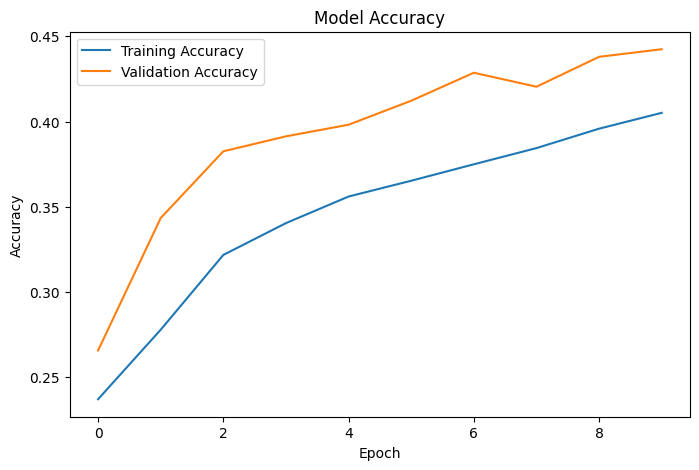

In [18]:
# Plot training and validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('/kaggle/working/outputs/figures/accuracy_plot.pdf')

plt.show()

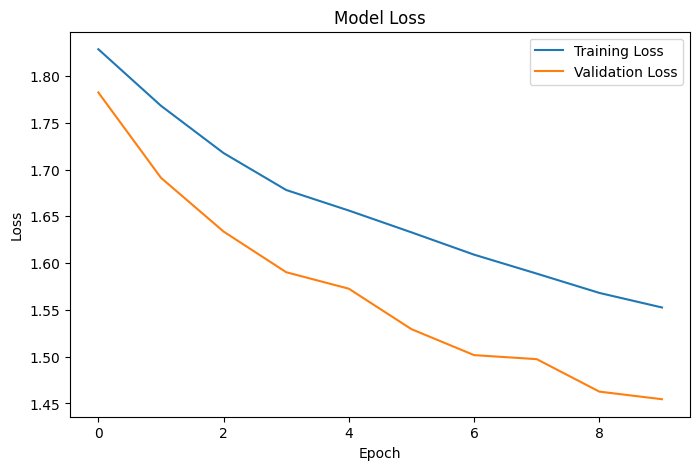

In [19]:
# Plot training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig('/kaggle/working/outputs/figures/loss_plot.pdf')

plt.show()

In [20]:
# Generate predictions

predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_names = list(test_data.class_indices.keys())

113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step


In [23]:
# Classification report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv('/kaggle/working/outputs/tables/classification_report.csv')

report_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
angry,0.363128,0.203549,0.260870,958.000000
disgust,0.000000,0.000000,0.000000,111.000000
fear,0.257407,0.135742,0.177749,1024.000000
happy,0.553770,0.757610,0.639848,1774.000000
neutral,0.382581,0.480941,0.426159,1233.000000
sad,0.417655,0.254210,0.316052,1247.000000
surprise,0.430769,0.707581,0.535519,831.000000
accuracy,0.442463,0.442463,0.442463,0.442463
macro avg,0.343616,0.362805,0.336599,7178.000000
weighted avg,0.410192,0.442463,0.408415,7178.000000


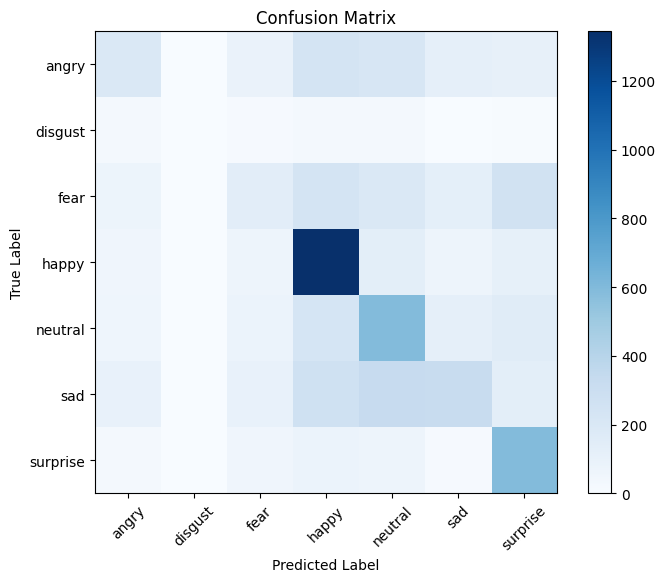

In [24]:
# Confusion Matrix

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.savefig('/kaggle/working/outputs/figures/confusion_matrix.pdf')

plt.show()




In [25]:
# Save confusion matrix as CSV table

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv('/kaggle/working/outputs/tables/confusion_matrix.csv')

cm_df

,angry,disgust,fear,happy,neutral,sad,surprise
angry,195,0,86,239,212,119,107
disgust,29,0,14,29,24,5,10
fear,71,0,139,235,196,121,262
happy,55,0,65,1344,135,63,112
neutral,59,0,81,227,593,119,154
sad,103,0,98,271,326,317,132
surprise,25,0,57,82,64,15,588


In [26]:
# Zip all outputs

import shutil

shutil.make_archive(
    '/kaggle/working/final_outputs',
    'zip',
    '/kaggle/working/outputs'
)

print("ZIP file created successfully")

ZIP file created successfully
